In [8]:
import pandas as pd
import numpy as np

In [9]:
df = pd.read_excel("../data/Telco_customer_churn.xlsx")

print("Dataset loaded successfully!")
print("Shape:", df.shape)

Dataset loaded successfully!
Shape: (7043, 33)


In [10]:
df.head()

,CustomerID,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,...,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason
0,3668-QPYBK,1,United States,California,Los Angeles,90003,"33.964131, -118.272783",33.964131,-118.272783,Male,...,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1,86,3239,Competitor made better offer
1,9237-HQITU,1,United States,California,Los Angeles,90005,"34.059281, -118.30742",34.059281,-118.307420,Female,...,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1,67,2701,Moved
2,9305-CDSKC,1,United States,California,Los Angeles,90006,"34.048013, -118.293953",34.048013,-118.293953,Female,...,Month-to-month,Yes,Electronic check,99.65,820.5,Yes,1,86,5372,Moved
3,7892-POOKP,1,United States,California,Los Angeles,90010,"34.062125, -118.315709",34.062125,-118.315709,Female,...,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes,1,84,5003,Moved
4,0280-XJGEX,1,United States,California,Los Angeles,90015,"34.039224, -118.266293",34.039224,-118.266293,Male,...,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.3,Yes,1,89,5340,Competitor had better devices


In [11]:
print("Target distribution:")
print(df["Churn Label"].value_counts())

print("\nTarget percentage:")
print(df["Churn Label"].value_counts(normalize=True) * 100)

Target distribution:
Churn Label
No     5174
Yes    1869
Name: count, dtype: int64

Target percentage:
Churn Label
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64


In [12]:
df.dtypes


CustomerID               str
Count                  int64
Country                  str
State                    str
City                     str
Zip Code               int64
Lat Long                 str
Latitude             float64
Longitude            float64
Gender                   str
Senior Citizen           str
Partner                  str
Dependents               str
Tenure Months          int64
Phone Service            str
Multiple Lines           str
Internet Service         str
Online Security          str
Online Backup            str
Device Protection        str
Tech Support             str
Streaming TV             str
Streaming Movies         str
Contract                 str
Paperless Billing        str
Payment Method           str
Monthly Charges      float64
Total Charges         object
Churn Label              str
Churn Value            int64
Churn Score            int64
CLTV                   int64
Churn Reason             str
dtype: object

In [13]:
df["Total Charges"].head(10)

0     108.15
1     151.65
2      820.5
3    3046.05
4     5036.3
5     528.35
6      39.65
7      20.15
8    4749.15
9       30.2
Name: Total Charges, dtype: object

In [14]:
df["Total Charges"].isna().sum()


np.int64(0)

In [15]:
df["Total Charges"].astype(str).str.strip().eq("").sum()

np.int64(11)

In [16]:
df.loc[
    df["Total Charges"].astype(str).str.strip().eq(""),
    ["CustomerID", "Tenure Months", "Total Charges", "Churn Label"]
]

,CustomerID,Tenure Months,Total Charges,Churn Label
2234,4472-LVYGI,0,,No
2438,3115-CZMZD,0,,No
2568,5709-LVOEQ,0,,No
2667,4367-NUYAO,0,,No
2856,1371-DWPAZ,0,,No
4331,7644-OMVMY,0,,No
4687,3213-VVOLG,0,,No
5104,2520-SGTTA,0,,No
5719,2923-ARZLG,0,,No
6772,4075-WKNIU,0,,No


In [17]:
df["Total Charges"] = pd.to_numeric(
    df["Total Charges"],
    errors="coerce"
)

In [18]:
print("Total Charges dtype:", df["Total Charges"].dtype)
print("Missing Total Charges:", df["Total Charges"].isna().sum())

Total Charges dtype: float64
Missing Total Charges: 11


In [19]:
df["Total Charges"] = df["Total Charges"].fillna(0)

In [20]:
print("Missing Total Charges:", df["Total Charges"].isna().sum())

Missing Total Charges: 0


In [21]:
print("Shape:", df.shape)
print("Duplicate rows:", df.duplicated().sum())
print("Missing values:")
print(df.isnull().sum()[df.isnull().sum() > 0])

Shape: (7043, 33)
Duplicate rows: 0
Missing values:
Churn Reason    5174
dtype: int64


In [22]:
drop_columns = [
    "CustomerID",
    "Count",
    "Country",
    "State",
    "City",
    "Zip Code",
    "Lat Long",
    "Latitude",
    "Longitude",
    "Churn Value",
    "Churn Score",
    "CLTV",
    "Churn Reason"
]

model_df = df.drop(columns=drop_columns)

print("Original shape:", df.shape)
print("Modeling dataset shape:", model_df.shape)

Original shape: (7043, 33)
Modeling dataset shape: (7043, 20)


In [23]:
print(model_df.columns.tolist())


['Gender', 'Senior Citizen', 'Partner', 'Dependents', 'Tenure Months', 'Phone Service', 'Multiple Lines', 'Internet Service', 'Online Security', 'Online Backup', 'Device Protection', 'Tech Support', 'Streaming TV', 'Streaming Movies', 'Contract', 'Paperless Billing', 'Payment Method', 'Monthly Charges', 'Total Charges', 'Churn Label']


In [24]:
X = model_df.drop(columns=["Churn Label"])
y = model_df["Churn Label"]

In [25]:
print("Features:", X.shape)
print("Target:", y.shape)

Features: (7043, 19)
Target: (7043,)


In [26]:
print("Target values:")
print(y.value_counts())

Target values:
Churn Label
No     5174
Yes    1869
Name: count, dtype: int64


In [27]:
print(X.dtypes)

Gender                   str
Senior Citizen           str
Partner                  str
Dependents               str
Tenure Months          int64
Phone Service            str
Multiple Lines           str
Internet Service         str
Online Security          str
Online Backup            str
Device Protection        str
Tech Support             str
Streaming TV             str
Streaming Movies         str
Contract                 str
Paperless Billing        str
Payment Method           str
Monthly Charges      float64
Total Charges        float64
dtype: object


In [28]:
print("\nUnique values per feature:")
print(X.nunique().sort_values())


Unique values per feature:
Gender                  2
Senior Citizen          2
Partner                 2
Dependents              2
Phone Service           2
Paperless Billing       2
Internet Service        3
Multiple Lines          3
Tech Support            3
Online Security         3
Device Protection       3
Online Backup           3
Streaming Movies        3
Streaming TV            3
Contract                3
Payment Method          4
Tenure Months          73
Monthly Charges      1585
Total Charges        6531
dtype: int64


In [29]:
contract_churn = pd.crosstab(
    X["Contract"],
    y,
    normalize="index"
) * 100

print(contract_churn)

Churn Label            No        Yes
Contract                            
Month-to-month  57.290323  42.709677
One year        88.730482  11.269518
Two year        97.168142   2.831858


Matplotlib is building the font cache; this may take a moment.


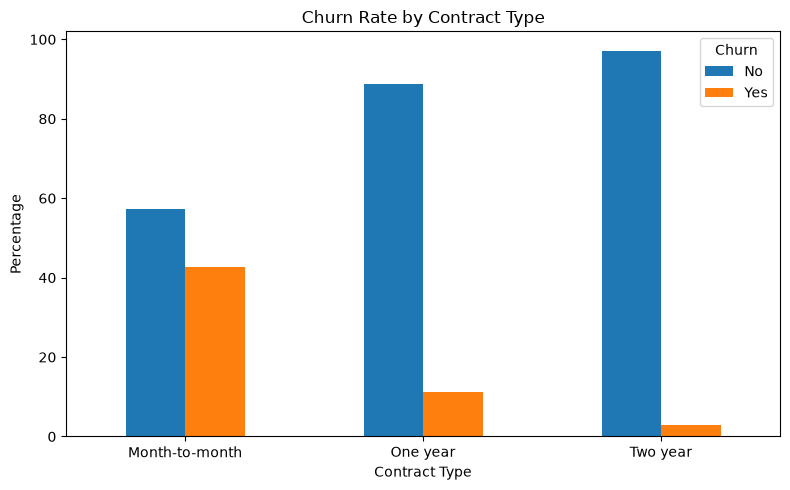

In [30]:
import matplotlib.pyplot as plt

contract_churn.plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("Churn Rate by Contract Type")
plt.xlabel("Contract Type")
plt.ylabel("Percentage")
plt.xticks(rotation=0)
plt.legend(title="Churn")
plt.tight_layout()
plt.show()

In [31]:
df["Tenure Group"] = pd.cut(
    df["Tenure Months"],
    bins=[-1, 6, 12, 24, 48, 72],
    labels=[
        "0-6 months",
        "7-12 months",
        "13-24 months",
        "25-48 months",
        "49-72 months"
    ]
)

In [32]:
tenure_churn = pd.crosstab(
    df["Tenure Group"],
    df["Churn Label"],
    normalize="index"
) * 100

print(tenure_churn)

Churn Label          No        Yes
Tenure Group                      
0-6 months    47.062795  52.937205
7-12 months   64.113475  35.886525
13-24 months  71.289062  28.710938
25-48 months  79.611041  20.388959
49-72 months  90.486824   9.513176


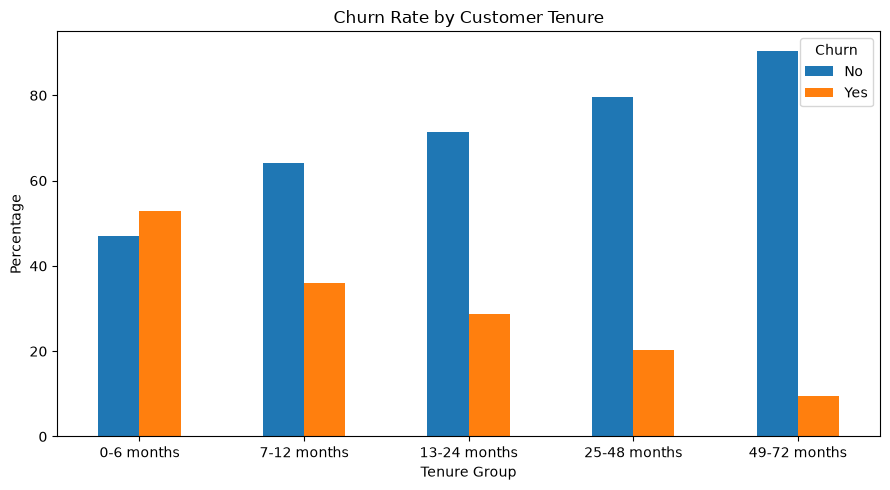

In [33]:
tenure_churn.plot(
    kind="bar",
    figsize=(9, 5)
)

plt.title("Churn Rate by Customer Tenure")
plt.xlabel("Tenure Group")
plt.ylabel("Percentage")
plt.xticks(rotation=0)
plt.legend(title="Churn")
plt.tight_layout()
plt.show()

In [34]:
df.groupby("Churn Label")["Monthly Charges"].describe()

,count,mean,std,min,25%,50%,75%,max
Churn Label,,,,,,,,
No,5174.0,61.265124,31.092648,18.25,25.10,64.425,88.4,118.75
Yes,1869.0,74.441332,24.666053,18.85,56.15,79.650,94.2,118.35


In [35]:
sns.boxplot(
    data=df,
    x="Churn Label",
    y="Monthly Charges"
)

plt.title("Monthly Charges by Churn Status")
plt.tight_layout()
plt.show()

NameError: name 'sns' is not defined

In [36]:
import matplotlib.pyplot as plt
import seaborn as sns

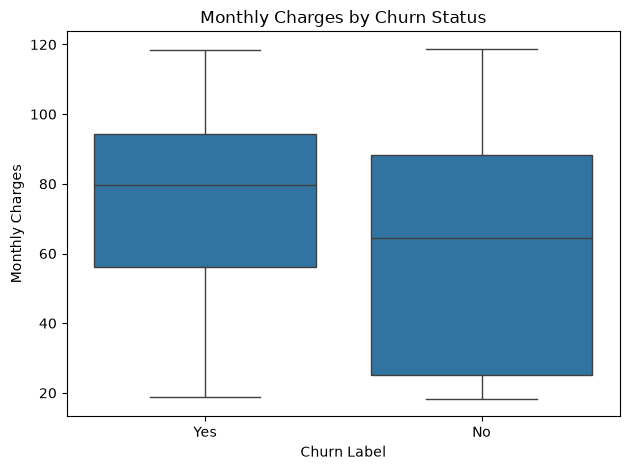

In [37]:
sns.boxplot(
    data=df,
    x="Churn Label",
    y="Monthly Charges"
)

plt.title("Monthly Charges by Churn Status")
plt.tight_layout()
plt.show()

In [38]:
internet_churn = pd.crosstab(
    X["Internet Service"],
    y,
    normalize="index"
) * 100

print(internet_churn)

Churn Label              No        Yes
Internet Service                      
DSL               81.040892  18.959108
Fiber optic       58.107235  41.892765
No                92.595020   7.404980


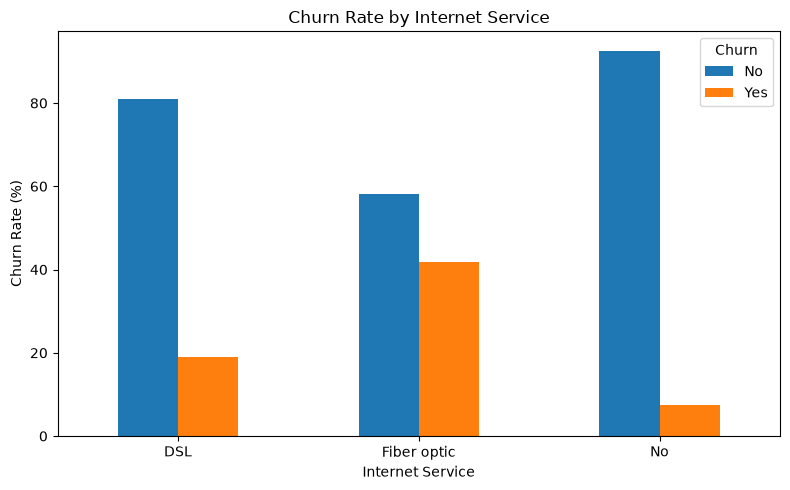

In [39]:
internet_churn.plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("Churn Rate by Internet Service")
plt.xlabel("Internet Service")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=0)
plt.legend(title="Churn")
plt.tight_layout()
plt.show()

In [40]:
payment_churn = pd.crosstab(
    X["Payment Method"],
    y,
    normalize="index"
) * 100

print(payment_churn)

Churn Label                       No        Yes
Payment Method                                 
Bank transfer (automatic)  83.290155  16.709845
Credit card (automatic)    84.756899  15.243101
Electronic check           54.714588  45.285412
Mailed check               80.893300  19.106700


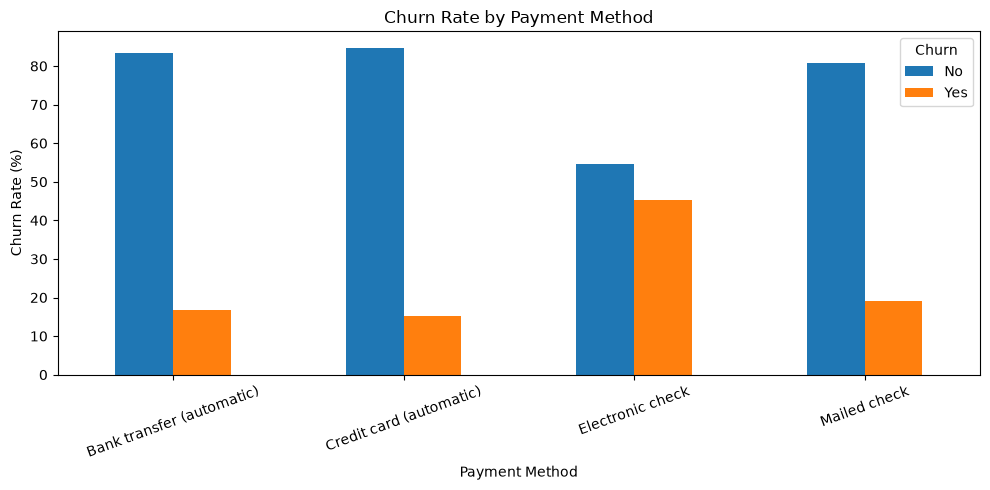

In [41]:
payment_churn.plot(
    kind="bar",
    figsize=(10, 5)
)

plt.title("Churn Rate by Payment Method")
plt.xlabel("Payment Method")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=20)
plt.legend(title="Churn")
plt.tight_layout()
plt.show()

In [42]:
support_churn = pd.crosstab(
    X["Tech Support"],
    y,
    normalize="index"
) * 100

print(support_churn)

Churn Label                 No        Yes
Tech Support                             
No                   58.364526  41.635474
No internet service  92.595020   7.404980
Yes                  84.833659  15.166341


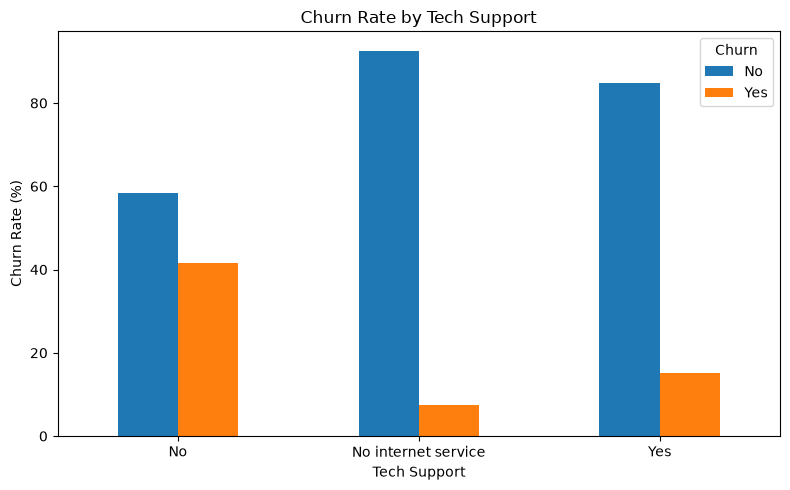

In [43]:
support_churn.plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("Churn Rate by Tech Support")
plt.xlabel("Tech Support")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=0)
plt.legend(title="Churn")
plt.tight_layout()
plt.show()

In [44]:
senior_churn = pd.crosstab(
    X["Senior Citizen"],
    y,
    normalize="index"
) * 100

print(senior_churn)

Churn Label            No        Yes
Senior Citizen                      
No              76.393832  23.606168
Yes             58.318739  41.681261


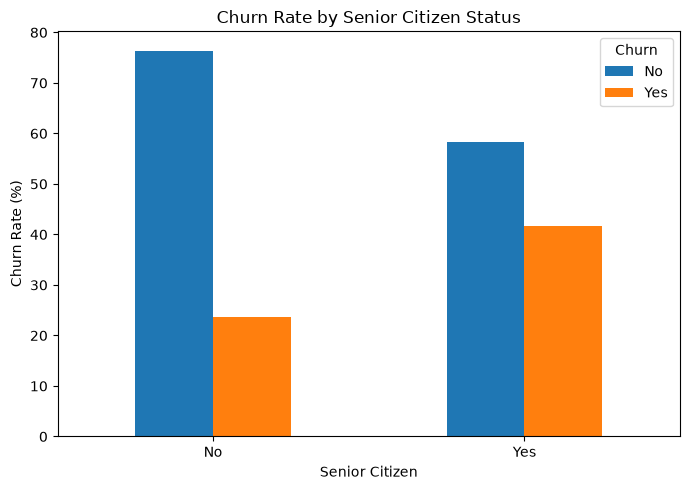

In [45]:
senior_churn.plot(
    kind="bar",
    figsize=(7, 5)
)

plt.title("Churn Rate by Senior Citizen Status")
plt.xlabel("Senior Citizen")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=0)
plt.legend(title="Churn")
plt.tight_layout()
plt.show()

In [48]:
y = y.map({
    "No": 0,
    "Yes": 1
})

print(y.value_counts())

Churn Label
0    5174
1    1869
Name: count, dtype: int64


In [49]:
df["Avg Monthly Spend"] = np.where(
    df["Tenure Months"] > 0,
    df["Total Charges"] / df["Tenure Months"],
    df["Monthly Charges"]
)

In [50]:
df[
    [
        "Tenure Months",
        "Monthly Charges",
        "Total Charges",
        "Avg Monthly Spend"
    ]
].head(10)

,Tenure Months,Monthly Charges,Total Charges,Avg Monthly Spend
0,2,53.85,108.15,54.075000
1,2,70.70,151.65,75.825000
2,8,99.65,820.50,102.562500
3,28,104.80,3046.05,108.787500
4,49,103.70,5036.30,102.781633
5,10,55.20,528.35,52.835000
6,1,39.65,39.65,39.650000
7,1,20.15,20.15,20.150000
8,47,99.35,4749.15,101.045745
9,1,30.20,30.20,30.200000


In [51]:
drop_columns = [
    "CustomerID",
    "Count",
    "Country",
    "State",
    "City",
    "Zip Code",
    "Lat Long",
    "Latitude",
    "Longitude",
    "Churn Value",
    "Churn Score",
    "CLTV",
    "Churn Reason",
    "Churn Label"
]

In [52]:
X = df.drop(columns=drop_columns)

In [54]:
numeric_features = X.select_dtypes(
    include=["number"]
).columns.tolist()

categorical_features = X.select_dtypes(
    include=["object", "str"]
).columns.tolist()

print("Numerical features:", numeric_features)
print("\nCategorical features:", categorical_features)

Numerical features: ['Tenure Months', 'Monthly Charges', 'Total Charges', 'Avg Monthly Spend']

Categorical features: ['Gender', 'Senior Citizen', 'Partner', 'Dependents', 'Phone Service', 'Multiple Lines', 'Internet Service', 'Online Security', 'Online Backup', 'Device Protection', 'Tech Support', 'Streaming TV', 'Streaming Movies', 'Contract', 'Paperless Billing', 'Payment Method']


In [55]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training:", X_train.shape)
print("Testing:", X_test.shape)

print("\nTraining target:")
print(y_train.value_counts(normalize=True))

print("\nTesting target:")
print(y_test.value_counts(normalize=True))

Training: (5634, 21)
Testing: (1409, 21)

Training target:
Churn Label
0    0.734647
1    0.265353
Name: proportion, dtype: float64

Testing target:
Churn Label
0    0.734564
1    0.265436
Name: proportion, dtype: float64


In [56]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            StandardScaler(),
            numeric_features
        ),
        (
            "cat",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_features
        )
    ]
)

In [57]:
X_train_processed = preprocessor.fit_transform(X_train)

X_test_processed = preprocessor.transform(X_test)

print("Processed training shape:", X_train_processed.shape)
print("Processed testing shape:", X_test_processed.shape)

Processed training shape: (5634, 47)
Processed testing shape: (1409, 47)


In [58]:
from sklearn.linear_model import LogisticRegression

In [59]:
logistic_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

In [60]:
logistic_model.fit(
    X_train_processed,
    y_train
)

,"random_state random_state: int, RandomState instance, default=NoneOnly used for `solver` == 'sag', 'saga' or 'liblinear' to shuffle thedata. It has no effect on the other solvers.See :term:`Glossary <random_state>` for details.",42
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in 

In [61]:
y_pred = logistic_model.predict(X_test_processed)

y_proba = logistic_model.predict_proba(
    X_test_processed
)[:, 1]

In [62]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_proba)

print("Logistic Regression Baseline")
print("----------------------------")
print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1 Score : {f1:.4f}")
print(f"ROC-AUC  : {roc_auc:.4f}")

Logistic Regression Baseline
----------------------------
Accuracy : 0.8027
Precision: 0.6446
Recall   : 0.5722
F1 Score : 0.6062
ROC-AUC  : 0.8487


In [63]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_test,
        y_pred,
        target_names=["No Churn", "Churn"]
    )
)

              precision    recall  f1-score   support

    No Churn       0.85      0.89      0.87      1035
       Churn       0.64      0.57      0.61       374

    accuracy                           0.80      1409
   macro avg       0.75      0.73      0.74      1409
weighted avg       0.80      0.80      0.80      1409



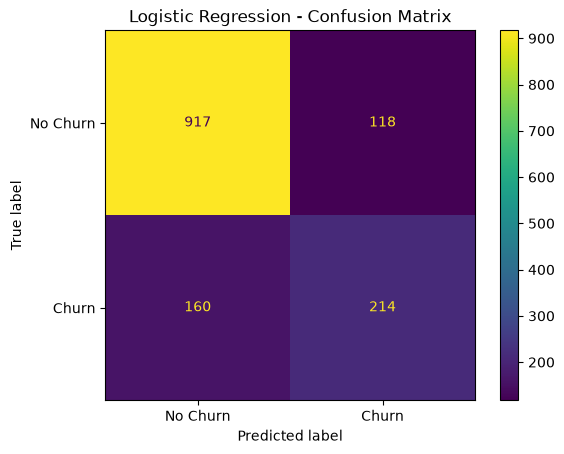

In [64]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["No Churn", "Churn"]
)

disp.plot()
plt.title("Logistic Regression - Confusion Matrix")
plt.show()

In [67]:
from sklearn.ensemble import RandomForestClassifier

In [68]:
random_forest = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    class_weight="balanced",
    n_jobs=-1
)

In [69]:
random_forest.fit(
    X_train_processed,
    y_train
)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",300
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel. :meth:`fit`, :meth:`predict`,:meth:`decision_path` and :meth:`apply` are all parallelized over thetrees. ``None`` means 1 unless in a :obj:`joblib.parallel_backend`context. ``-1`` means using all processors. See :term:`Glossary<n_jobs>` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"class_weight class_weight: {""balanced"", ""balanced_subsample""}, dict or list of dicts, default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one. Formulti-output problems, a list of dicts can be provided in the sameorder as the columns of y.Note that for multioutput (including multilabel) weights should bedefined for each class of every column in its own dict. For example,for four-class multilabel classification weights should be[{0: 1, 1: 1}, {0: 1, 1: 5}, {0: 1, 1: 1}, {0: 1, 1: 1}] instead of[{1:1}, {2:5}, {3:1}, {4:1}].The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``The ""balanced_subsample"" mode is the same as ""balanced"" except thatweights are computed based on the bootstrap sample for every treegrown.For multi-output, the weights of each column of y will be multiplied.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified.",'balanced'
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_fe

In [70]:
rf_pred = random_forest.predict(X_test_processed)

rf_proba = random_forest.predict_proba(
    X_test_processed
)[:, 1]

In [71]:
rf_accuracy = accuracy_score(y_test, rf_pred)
rf_precision = precision_score(y_test, rf_pred)
rf_recall = recall_score(y_test, rf_pred)
rf_f1 = f1_score(y_test, rf_pred)
rf_roc_auc = roc_auc_score(y_test, rf_proba)

print("Random Forest")
print("-------------")
print(f"Accuracy : {rf_accuracy:.4f}")
print(f"Precision: {rf_precision:.4f}")
print(f"Recall   : {rf_recall:.4f}")
print(f"F1 Score : {rf_f1:.4f}")
print(f"ROC-AUC  : {rf_roc_auc:.4f}")

Random Forest
-------------
Accuracy : 0.7722
Precision: 0.5618
Recall   : 0.6444
F1 Score : 0.6002
ROC-AUC  : 0.8358


In [72]:
print(
    classification_report(
        y_test,
        rf_pred,
        target_names=["No Churn", "Churn"]
    )
)

              precision    recall  f1-score   support

    No Churn       0.86      0.82      0.84      1035
       Churn       0.56      0.64      0.60       374

    accuracy                           0.77      1409
   macro avg       0.71      0.73      0.72      1409
weighted avg       0.78      0.77      0.78      1409



In [77]:
from xgboost import XGBClassifier

In [78]:
xgb_model = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric="logloss"
)

In [79]:
xgb_model.fit(
    X_train_processed,
    y_train
)

,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",'logloss'
,feature_types feature_types: typing.Optional[typing.Sequence[str]].. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


In [80]:
xgb_pred = xgb_model.predict(X_test_processed)

xgb_proba = xgb_model.predict_proba(
    X_test_processed
)[:, 1]

In [81]:
xgb_accuracy = accuracy_score(y_test, xgb_pred)
xgb_precision = precision_score(y_test, xgb_pred)
xgb_recall = recall_score(y_test, xgb_pred)
xgb_f1 = f1_score(y_test, xgb_pred)
xgb_roc_auc = roc_auc_score(y_test, xgb_proba)

print("XGBoost")
print("-------")
print(f"Accuracy : {xgb_accuracy:.4f}")
print(f"Precision: {xgb_precision:.4f}")
print(f"Recall   : {xgb_recall:.4f}")
print(f"F1 Score : {xgb_f1:.4f}")
print(f"ROC-AUC  : {xgb_roc_auc:.4f}")

XGBoost
-------
Accuracy : 0.8034
Precision: 0.6601
Recall   : 0.5348
F1 Score : 0.5908
ROC-AUC  : 0.8547


In [82]:
print(
    classification_report(
        y_test,
        xgb_pred,
        target_names=["No Churn", "Churn"]
    )
)

              precision    recall  f1-score   support

    No Churn       0.84      0.90      0.87      1035
       Churn       0.66      0.53      0.59       374

    accuracy                           0.80      1409
   macro avg       0.75      0.72      0.73      1409
weighted avg       0.79      0.80      0.80      1409



In [83]:
model_results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest",
        "XGBoost"
    ],
    "Accuracy": [
        accuracy,
        rf_accuracy,
        xgb_accuracy
    ],
    "Precision": [
        precision,
        rf_precision,
        xgb_precision
    ],
    "Recall": [
        recall,
        rf_recall,
        xgb_recall
    ],
    "F1": [
        f1,
        rf_f1,
        xgb_f1
    ],
    "ROC-AUC": [
        roc_auc,
        rf_roc_auc,
        xgb_roc_auc
    ]
})

model_results.round(4)

,Model,Accuracy,Precision,Recall,F1,ROC-AUC
0,Logistic Regression,0.8027,0.6446,0.5722,0.6062,0.8487
1,Random Forest,0.7722,0.5618,0.6444,0.6002,0.8358
2,XGBoost,0.8034,0.6601,0.5348,0.5908,0.8547


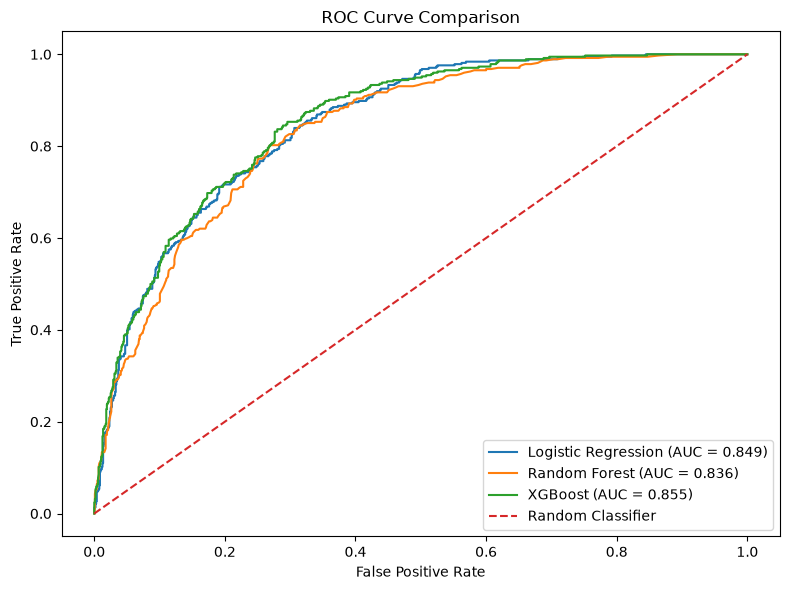

In [84]:
from sklearn.metrics import roc_curve

lr_fpr, lr_tpr, _ = roc_curve(y_test, y_proba)
rf_fpr, rf_tpr, _ = roc_curve(y_test, rf_proba)
xgb_fpr, xgb_tpr, _ = roc_curve(y_test, xgb_proba)

plt.figure(figsize=(8, 6))

plt.plot(
    lr_fpr,
    lr_tpr,
    label=f"Logistic Regression (AUC = {roc_auc:.3f})"
)

plt.plot(
    rf_fpr,
    rf_tpr,
    label=f"Random Forest (AUC = {rf_roc_auc:.3f})"
)

plt.plot(
    xgb_fpr,
    xgb_tpr,
    label=f"XGBoost (AUC = {xgb_roc_auc:.3f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Classifier"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.tight_layout()
plt.show()

In [85]:
y_proba
rf_proba
xgb_proba

array([0.02670101, 0.89495325, 0.14396846, ..., 0.12332515, 0.07622065,
       0.00232519], shape=(1409,), dtype=float32)

In [86]:
from sklearn.metrics import precision_score, recall_score, f1_score

def threshold_metrics(y_true, probabilities, thresholds):
    results = []

    for threshold in thresholds:
        predictions = (probabilities >= threshold).astype(int)

        results.append({
            "Threshold": threshold,
            "Precision": precision_score(y_true, predictions),
            "Recall": recall_score(y_true, predictions),
            "F1": f1_score(y_true, predictions)
        })

    return pd.DataFrame(results)

In [87]:
thresholds = [0.30, 0.35, 0.40, 0.45, 0.50, 0.55, 0.60]

lr_threshold_results = threshold_metrics(
    y_test,
    y_proba,
    thresholds
)

lr_threshold_results.round(3)

,Threshold,Precision,Recall,F1
0,0.30,0.531,0.743,0.619
1,0.35,0.561,0.717,0.629
2,0.40,0.579,0.674,0.623
3,0.45,0.607,0.628,0.618
4,0.50,0.645,0.572,0.606
5,0.55,0.667,0.508,0.577
6,0.60,0.721,0.441,0.547


In [88]:
thresholds = [0.30, 0.40, 0.50, 0.60, 0.70]

all_threshold_results = []

for model_name, probabilities in [
    ("Logistic Regression", y_proba),
    ("Random Forest", rf_proba),
    ("XGBoost", xgb_proba)
]:

    for threshold in thresholds:

        predictions = (
            probabilities >= threshold
        ).astype(int)

        all_threshold_results.append({
            "Model": model_name,
            "Threshold": threshold,
            "Precision": precision_score(
                y_test,
                predictions
            ),
            "Recall": recall_score(
                y_test,
                predictions
            ),
            "F1": f1_score(
                y_test,
                predictions
            )
        })

threshold_comparison = pd.DataFrame(
    all_threshold_results
)

threshold_comparison.round(3)

,Model,Threshold,Precision,Recall,F1
0,Logistic Regression,0.3,0.531,0.743,0.619
1,Logistic Regression,0.4,0.579,0.674,0.623
2,Logistic Regression,0.5,0.645,0.572,0.606
3,Logistic Regression,0.6,0.721,0.441,0.547
4,Logistic Regression,0.7,0.763,0.241,0.366
5,Random Forest,0.3,0.470,0.853,0.606
6,Random Forest,0.4,0.526,0.773,0.626
7,Random Forest,0.5,0.555,0.644,0.597
8,Random Forest,0.6,0.621,0.561,0.590
9,Random Forest,0.7,0.649,0.430,0.518


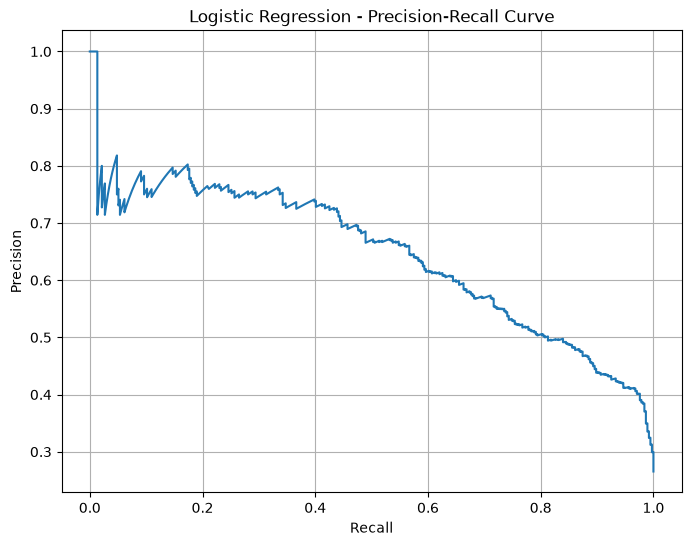

In [89]:
from sklearn.metrics import precision_recall_curve

lr_precision, lr_recall, lr_thresholds = precision_recall_curve(
    y_test,
    y_proba
)

plt.figure(figsize=(8, 6))

plt.plot(
    lr_recall,
    lr_precision
)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Logistic Regression - Precision-Recall Curve")
plt.grid()
plt.show()

In [90]:
from sklearn.model_selection import StratifiedKFold, cross_val_score

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

In [91]:
from sklearn.pipeline import Pipeline

lr_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(
        max_iter=1000,
        random_state=42
    ))
])

rf_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestClassifier(
        n_estimators=300,
        random_state=42,
        class_weight="balanced",
        n_jobs=-1
    ))
])

xgb_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", XGBClassifier(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=4,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        eval_metric="logloss"
    ))
])

In [92]:
lr_cv = cross_val_score(
    lr_pipeline,
    X_train,
    y_train,
    cv=cv,
    scoring="f1"
)

rf_cv = cross_val_score(
    rf_pipeline,
    X_train,
    y_train,
    cv=cv,
    scoring="f1"
)

xgb_cv = cross_val_score(
    xgb_pipeline,
    X_train,
    y_train,
    cv=cv,
    scoring="f1"
)

In [93]:
print("Logistic Regression CV F1:", lr_cv.mean())
print("Random Forest CV F1:", rf_cv.mean())
print("XGBoost CV F1:", xgb_cv.mean())

Logistic Regression CV F1: 0.6228150973875339
Random Forest CV F1: 0.6256237516837173
XGBoost CV F1: 0.5989876672198778


In [94]:
feature_names = preprocessor.get_feature_names_out()

rf_importance = random_forest.feature_importances_

feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": rf_importance
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance.head(15)

,Feature,Importance
2,num__Total Charges,0.115361
0,num__Tenure Months,0.108431
3,num__Avg Monthly Spend,0.098722
1,num__Monthly Charges,0.093990
38,cat__Contract_Month-to-month,0.074994
20,cat__Online Security_No,0.039573
29,cat__Tech Support_No,0.031257
40,cat__Contract_Two year,0.030392
10,cat__Dependents_No,0.028222
11,cat__Dependents_Yes,0.026291


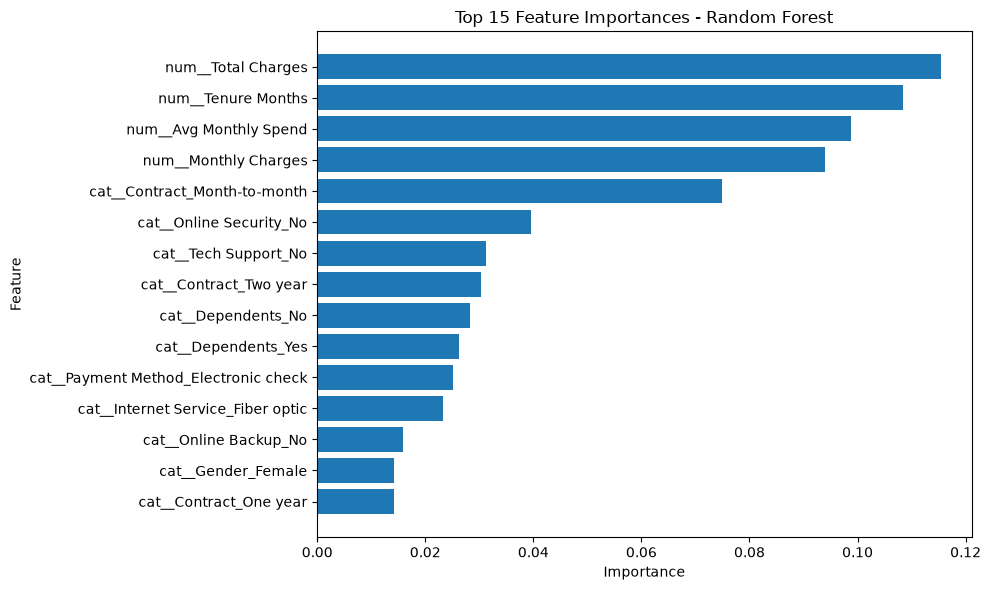

In [95]:
top_features = feature_importance.head(15).sort_values(
    by="Importance"
)

plt.figure(figsize=(10, 6))

plt.barh(
    top_features["Feature"],
    top_features["Importance"]
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Top 15 Feature Importances - Random Forest")

plt.tight_layout()
plt.show()

In [96]:
# Train final Random Forest pipeline

rf_pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](21,)","['Gender','Senior Citizen','Partner',...,'Total Charges','Tenure Group', 'Avg Monthly Spend']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,21
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder

In [97]:
final_pred = rf_pipeline.predict(X_test)
final_proba = rf_pipeline.predict_proba(X_test)[:, 1]

In [98]:
from sklearn.metrics import classification_report

print(classification_report(
    y_test,
    final_pred,
    target_names=["No Churn", "Churn"]
))

              precision    recall  f1-score   support

    No Churn       0.86      0.82      0.84      1035
       Churn       0.56      0.64      0.60       374

    accuracy                           0.77      1409
   macro avg       0.71      0.73      0.72      1409
weighted avg       0.78      0.77      0.78      1409



In [99]:
from sklearn.metrics import roc_auc_score

final_roc_auc = roc_auc_score(
    y_test,
    final_proba
)

print("Final ROC-AUC:", final_roc_auc)

Final ROC-AUC: 0.8358017515306517


In [101]:
import joblib

joblib.dump(
    rf_pipeline,
    "../models/churn_model_pipeline.pkl"
)

print("Final model saved successfully!")

Final model saved successfully!


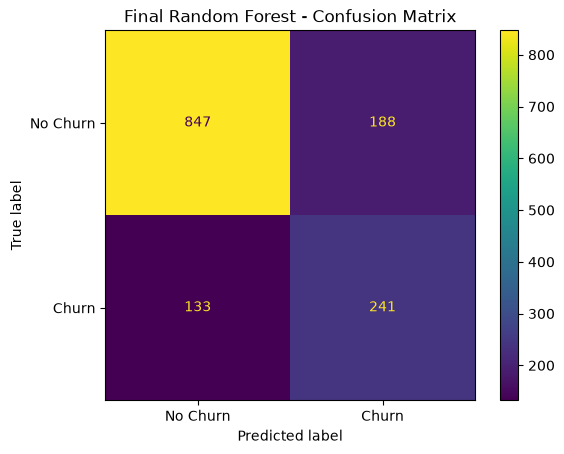

In [100]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, final_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["No Churn", "Churn"]
)

disp.plot()
plt.title("Final Random Forest - Confusion Matrix")
plt.show()

In [102]:
import joblib

loaded_model = joblib.load(
    "../models/churn_model_pipeline.pkl"
)

print("Model loaded successfully!")

Model loaded successfully!


In [103]:
test_predictions = loaded_model.predict(X_test)

print("Predictions generated successfully!")
print(test_predictions[:10])

Predictions generated successfully!
[0 1 0 1 0 1 1 0 0 1]


In [104]:
from sklearn.metrics import accuracy_score

loaded_accuracy = accuracy_score(
    y_test,
    test_predictions
)

print("Loaded Model Accuracy:", loaded_accuracy)

Loaded Model Accuracy: 0.7721788502484032
